# Bài giảng: Model Time-Series được train như thế nào?

Notebook này dành cho người mới, tập trung vào **logic train** hơn là chạy nhanh.

Bạn sẽ học:
1. Vì sao Time-Series không dùng random split
2. Expanding-window CV hoạt động ra sao
3. Linear Regression học gì từ cột `Date`
4. Cách nối từ CV sang train full và tạo submission

## Mục lục nhanh

- Phần A: Demo dữ liệu giả lập để hiểu nguyên lý
- Phần B: Áp dụng trên dữ liệu thật (`sales.csv`)
- Phần C: Liên hệ với pipeline chính trong `src/forecasting.py`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (11, 4)
np.random.seed(42)

## Phần A - Dữ liệu giả lập để hiểu nguyên lý

In [2]:
# Tạo chuỗi thời gian giả lập có trend + seasonality + noise
n = 240
dates = pd.date_range('2024-01-01', periods=n, freq='D')
trend = np.linspace(2_000_000, 5_500_000, n)
weekly = 300_000 * np.sin(2 * np.pi * np.arange(n) / 7)
noise = np.random.normal(0, 120_000, n)
revenue = trend + weekly + noise

toy_df = pd.DataFrame({'Date': dates, 'Revenue': revenue})
toy_df.head()

,Date,Revenue
0,2024-01-01,2.059606e+06
1,2024-01-02,2.232602e+06
2,2024-01-03,2.399490e+06
3,2024-01-04,2.356862e+06
4,2024-01-05,1.900314e+06


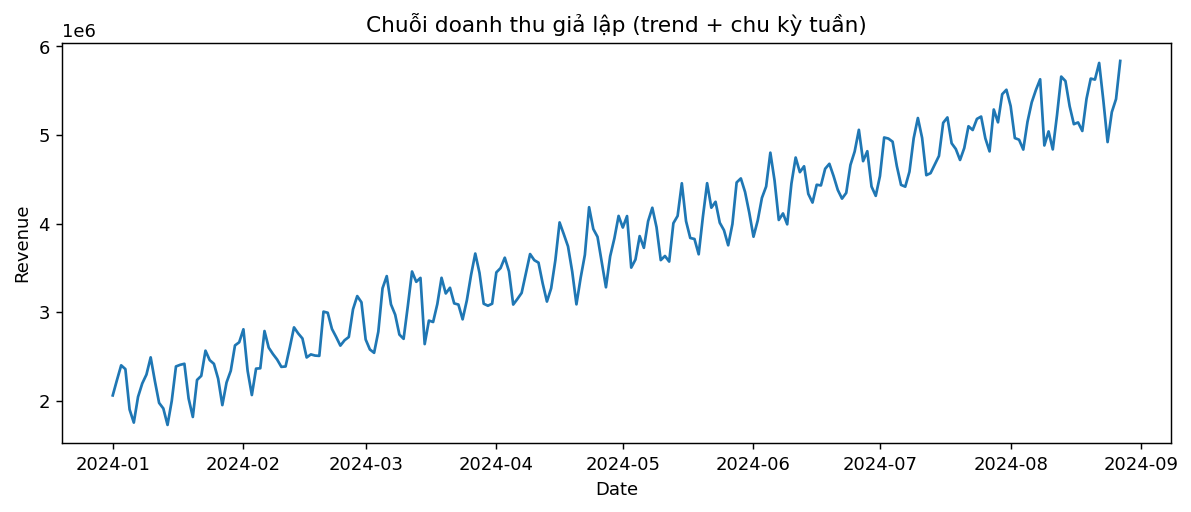

In [3]:
plt.plot(toy_df['Date'], toy_df['Revenue'])
plt.title('Chuỗi doanh thu giả lập (trend + chu kỳ tuần)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

### Expanding-window CV

Ta định nghĩa:
- `min_train_size`: số dòng train của fold đầu
- `valid_size`: số dòng validate mỗi fold
- `n_folds`: số fold

Mỗi fold mới sẽ mở rộng tập train về phía tương lai.

In [4]:
def generate_expanding_splits(n_rows: int, n_folds: int, valid_size: int, min_train_size: int):
    need = min_train_size + n_folds * valid_size
    if n_rows < need:
        raise ValueError(f'Khong du du lieu: can {need}, hien co {n_rows}')
    splits = []
    for i in range(n_folds):
        train_end = min_train_size + i * valid_size
        valid_start = train_end
        valid_end = valid_start + valid_size
        splits.append((train_end, valid_start, valid_end))
    return splits

splits = generate_expanding_splits(len(toy_df), n_folds=4, valid_size=20, min_train_size=100)
splits

[(100, 100, 120), (120, 120, 140), (140, 140, 160), (160, 160, 180)]

In [5]:
split_table = pd.DataFrame(
    [
        {
            'fold': i + 1,
            'train_index': f'0..{train_end - 1}',
            'valid_index': f'{valid_start}..{valid_end - 1}',
            'train_rows': train_end,
            'valid_rows': valid_end - valid_start,
        }
        for i, (train_end, valid_start, valid_end) in enumerate(splits)
    ]
)
split_table

,fold,train_index,valid_index,train_rows,valid_rows
0,1,0..99,100..119,100,20
1,2,0..119,120..139,120,20
2,3,0..139,140..159,140,20
3,4,0..159,160..179,160,20


### Feature engineering từ Date

Linear Regression không hiểu trực tiếp datetime, nên ta biến đổi `Date` thành các feature số.

In [6]:
def date_features(dates: pd.Series, origin: pd.Timestamp) -> pd.DataFrame:
    days_since = (dates - origin).dt.days.astype(float)
    day_of_week = dates.dt.dayofweek.astype(float)
    month = dates.dt.month.astype(float)
    day_of_year = dates.dt.dayofyear.astype(float)
    week_sin = np.sin(2.0 * np.pi * day_of_week / 7.0)
    week_cos = np.cos(2.0 * np.pi * day_of_week / 7.0)
    year_sin = np.sin(2.0 * np.pi * day_of_year / 365.25)
    year_cos = np.cos(2.0 * np.pi * day_of_year / 365.25)
    return pd.DataFrame(
        {
            'days_since': days_since,
            'day_of_week': day_of_week,
            'month': month,
            'week_sin': week_sin,
            'week_cos': week_cos,
            'year_sin': year_sin,
            'year_cos': year_cos,
        }
    )

In [7]:
def evaluate(y_true, y_pred):
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'r2': float(r2_score(y_true, y_pred)),
    }

rows = []
for fold, (train_end, valid_start, valid_end) in enumerate(splits, start=1):
    train_df = toy_df.iloc[:train_end].copy()
    valid_df = toy_df.iloc[valid_start:valid_end].copy()

    origin = train_df['Date'].min()
    x_train = date_features(train_df['Date'], origin)
    y_train = train_df['Revenue'].to_numpy()
    x_valid = date_features(valid_df['Date'], origin)
    y_valid = valid_df['Revenue'].to_numpy()

    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_valid)

    rows.append({'fold': fold, **evaluate(y_valid, y_pred)})

toy_cv_df = pd.DataFrame(rows)
toy_cv_df

,fold,mae,rmse,r2
0,1,172817.890048,213539.074615,0.462500
1,2,105711.221560,122450.439555,0.742426
2,3,122735.894341,142654.175645,0.689715
3,4,109536.156661,137991.167986,0.665143


In [8]:
print('CV trung bình (toy data):')
toy_cv_df[['mae', 'rmse', 'r2']].mean().to_dict()

CV trung bình (toy data):


{'mae': 127700.29065231286,
 'rmse': 154158.71445018682,
 'r2': 0.639946050942554}

## Phần B - Áp dụng nhanh trên dữ liệu thật

In [9]:
ROOT = Path('..').resolve()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'

sales_path = (PROCESSED_DIR / 'sales.csv') if (PROCESSED_DIR / 'sales.csv').exists() else (RAW_DIR / 'sales.csv')

sales_df = pd.read_csv(sales_path, low_memory=False)
sales_df['Date'] = pd.to_datetime(sales_df['Date'], errors='coerce')
sales_df['Revenue'] = pd.to_numeric(sales_df['Revenue'], errors='coerce')
sales_df = sales_df.dropna(subset=['Date', 'Revenue']).sort_values('Date').drop_duplicates('Date', keep='last').reset_index(drop=True)

sales_df[['Date', 'Revenue']].head()

,Date,Revenue
0,2012-07-04,5123547.94
1,2012-07-05,2751773.45
2,2012-07-06,3054029.42
3,2012-07-07,2667930.94
4,2012-07-08,2360851.90


In [10]:
CV_FOLDS = 5
CV_VALID_SIZE = 30
CV_MIN_TRAIN_SIZE = 180

real_splits = generate_expanding_splits(
    len(sales_df),
    n_folds=CV_FOLDS,
    valid_size=CV_VALID_SIZE,
    min_train_size=CV_MIN_TRAIN_SIZE,
)

pd.DataFrame(
    [
        {
            'fold': i + 1,
            'train_rows': train_end,
            'valid_rows': valid_end - valid_start,
        }
        for i, (train_end, valid_start, valid_end) in enumerate(real_splits)
    ]
)

,fold,train_rows,valid_rows
0,1,180,30
1,2,210,30
2,3,240,30
3,4,270,30
4,5,300,30


In [11]:
real_rows = []
for fold, (train_end, valid_start, valid_end) in enumerate(real_splits, start=1):
    train_df = sales_df.iloc[:train_end].copy()
    valid_df = sales_df.iloc[valid_start:valid_end].copy()

    origin = train_df['Date'].min()
    x_train = date_features(train_df['Date'], origin)
    y_train = train_df['Revenue'].to_numpy()
    x_valid = date_features(valid_df['Date'], origin)
    y_valid = valid_df['Revenue'].to_numpy()

    model = LinearRegression()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_valid)

    real_rows.append({'fold': fold, **evaluate(y_valid, y_pred)})

real_cv_df = pd.DataFrame(real_rows)
display(real_cv_df)
print('\nCV trung bình (real data):')
print(real_cv_df[['mae', 'rmse', 'r2']].mean().to_dict())

,fold,mae,rmse,r2
0,1,2.415701e+07,2.459685e+07,-589.285915
1,2,2.073948e+06,2.245091e+06,-1.704347
2,3,2.026522e+06,2.352016e+06,-0.071968
3,4,1.950729e+06,2.248901e+06,0.108877
4,5,2.947402e+06,3.172778e+06,-0.822421



CV trung bình (real data):
{'mae': 6631122.837646124, 'rmse': 6923127.809731992, 'r2': -118.35515475855432}


## Phần C - Kết nối với pipeline chính

- Các bước bạn vừa chạy thủ công tương đương logic trong `src/forecasting.py`
- Chạy lệnh dưới để có full pipeline (tạo cả submission + metrics):

```bash
uv run src/forecasting.py --method linear_regression --cv-folds 5 --cv-valid-size 30 --cv-min-train-size 180
```

Nếu muốn auto chọn model tốt hơn theo CV MAE:

```bash
uv run src/forecasting.py --method auto --cv-folds 5 --cv-valid-size 30 --cv-min-train-size 180
```